<a href="https://colab.research.google.com/github/FrancescaMicu/3DUPB_Computer_Vision/blob/main/proiect3DUPB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json, random, copy, re, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42)

In [2]:
# instalare api-uri
!pip install transformers accelerate bitsandbytes matplotlib

#
GRID_W, GRID_H = 16, 16
# codificarea hartii
# Bird -> zona blocata
# Normal Ladder -> pas inainte
# Start -> baza de inceput
# Exit -> Iesirea
# Beetle -> inamicul care trebuie ocolit cu orice pret (altfel se pierde jocul)
# Portal -> te teleporteaza la cealalta iesire a portalului
# Vines -> pas inainte dublu
# Broken Ladder -> coborare cu un rand mai jos fortata
TILE = {
    0:('.','#1a1a2e','Bird'),
    1:('N','#dfe6e9','Normal Ladder'),
    2:('S','#00b894','Start'),
    3:('E','#d63031','Exit'),
    4:('K','#f39c12','Beetle'),
    5:('P','#8e44ad','Portal'),
    6:('V','#c0392b','Vines'),
    7:('B','#f1c40f','Broken Ladder'),
    # 8:('+', '#ffd700', 'Golden Ladder')
}

PASSABLE = {1, 2, 3, 4, 5, 6, 7, 8}
COLORS = {k:v[1] for k, v in TILE.items()}
ASCII_MAP = {v[0]:k for k, v in TILE.items()}
VALID_CHARS = set(ASCII_MAP.keys())
print(VALID_CHARS)

print('✅ Config OK — Joc: Climb the Tower — Grid:', GRID_W, 'x', GRID_H)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 19.0 MB/s eta 0:00:00
{'K', 'N', 'E', 'B', '.', 'P', 'S', 'V'}
✅ Config OK — Joc: Climb the Tower — Grid: 16 x 16


In [ ]:
# descarcam LLM-ul

# conectare cu google colab
from google.colab import drive
from huggingface_hub import snapshot_download

drive.mount('/content/drive')

snapshot_download(
    repo_id="HuggingFaceTB/SmolLM2-1.7B-Instruct",
    local_dir="/content/drive/MyDrive/models/smollm2",
    ignore_patterns=["*.msgpack","*.h5","flax_*"],
)

print("✅ Model salvat în Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 28 files:   0%|          | 0/28 [00:00<?, ?it/s]

✅ Model salvat în Drive!


In [4]:
# incarcare din drive
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from google.colab import drive

drive.mount('/content/drive')
MODEL_ID = "/content/drive/MyDrive/models/smollm2"

print(f'🔄 Încărcare model din Drive...')
print(f'   GPU: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb, device_map='auto')
model.eval()
print('✅ Model încărcat din Drive!')

Mounted at /content/drive
🔄 Încărcare model din Drive...
   GPU: True
   VRAM: 15.6 GB


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

✅ Model încărcat din Drive!


In [58]:
# generare nivel folosind smollm2

# pregatirea promptului
SYSTEM = """You are a game level designer. Generate a tree-climbing level as ASCII art

Characters: . = Bird, N = Normal Ladder, S = Start, E = Exit, K = Beetle, P = Portal, V = Vines, B = Broken Ladder

CRITICAL RULES:
1. EXACTLY 16 lines of 16 characters. NO explanation text.
2. Draw a winding path from 'S' (bottom row) to 'E' (top row).
3. The path 'N' MUST be 2 to 3 characters thick to allow the player room to dodge.
5. Around 50-60% of the grid must be empty (.)."""

USER = """....NN..EB......
..NNNNNNN.......
..NNNB.........
..NNNNNNNNNNN...
..........BNN...
.....NNN...BN...
..NNNNNNNNNNN...
..N....NNN......
..P...NN........
..NNNNNNN.......
.......BN.......
.......KN.......
..NNKNNNN.......
..NNN...........
..PN...NB.......
..NNNNNNS.......

Modify this level to make it more interesting. Output ONLY the 16 lines, with no other text."""

def calling_llm(system, user, temp = 0.4, max_new = 400):
  msgs = [{'role':'system','content':system}, {'role':'user','content':user}]
  txt  = tokenizer.apply_chat_template(msgs, tokenize = False, add_generation_prompt = True)
  inp  = tokenizer(txt, return_tensors='pt').to(model.device)
  with torch.no_grad():
      out = model.generate(**inp, max_new_tokens = max_new, temperature=temp,
              do_sample=True, top_p=0.9,
              pad_token_id=tokenizer.eos_token_id)
  return tokenizer.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)

def parse_ascii_permisive(resp):
  lines = []

  # harta trebuie sa aiba exact GRID_W caractere
  for raw_line in resp.strip().split('\n'):
    line = raw_line.strip()
    if not line or len(line) < GRID_W / 4:
      continue
    cleaned = ''.join(c if c in VALID_CHARS else '.' for c in line)
    if len(cleaned) < GRID_W / 2:
      continue
    if len(cleaned) > GRID_W:
      cleaned = cleaned[:GRID_W]

    if len(cleaned) < GRID_W:
      pad = '.'
      cleaned = cleaned + pad * (GRID_W - len(cleaned))

    lines.append([ASCII_MAP.get(c, 1) for c in cleaned])
    if len(lines) == GRID_H:
      break

  # harta are prea putin linii
  while len(lines) < GRID_H:
    lines.append([0] * GRID_W)

  # ne asiguram ca harta are exact cate linii are nevoie
  return lines[:GRID_H]

print('✅ Functii de apel llm si de parsare definite')



✅ Functii de apel llm si de parsare definite


In [78]:
from collections import deque

# functii de parsare
def find_tiles(g, tid):
  hits = []
  for r, row in enumerate(g):
    for c, t in enumerate(row):
      if t == tid:
        hits.append((r,c))
  return hits

def find_tile(g, tid):
    for r, row in enumerate(g):
        for c, t in enumerate(row):
            if t == tid:
              return(r,c)
    return None

# functie de validare prin bfs
# def bfs(g, start, goal, passable, portals):
#   if not start or not goal:
#     return False, 0
#   if start == goal:
#     return True, 0
#   q = deque([(start,0)]);
#   vis = {start}
#   while q:
#     (r, c), d = q.popleft()

#     moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
#     neighbors = []

#     for dr, dc in moves:
#       # logica de broken ladder
#       if g[r][c] == 7 and dr == -1:
#         continue

#       nr, nc = r + dr, c + dc

#       # logica de normal ladder
#       if g[r][c] == 6 and dr == -1:
#         nr = r - 2

#       neighbors.append((nr, nc))

#     # validare bfs pentru portal
#     if (r, c) in portals and len(portals) == 2:
#       other_portal = portals[1] if portals[0] == (r, c) else portals[0]
#       neighbors.append(other_portal)

#     for nr,nc in neighbors:
#       if not(0 <= nr < GRID_H and 0 <= nc < GRID_W):
#         continue
#       if (nr,nc) in vis:
#         continue
#       if (nr,nc) == goal:
#         return True, d+1
#       if g[nr][nc] in passable:
#         vis.add((nr,nc))
#         q.append(((nr, nc),d+1))
#   return False, 0

from collections import deque

def bfs(g, start, goal, passable, portals):
    if not start or not goal:
        return False, 0
    if start == goal:
        return True, 0

    q = deque([(start, 0)])
    vis = {start}

    while q:
        (r, c), d = q.popleft()

        # ==========================================
        # FIZICA MIȘCĂRII
        # ==========================================
        if g[r][c] == 7:
            # ⛔ BROKEN LADDER: Cădere forțată! Singura direcție posibilă este JOS.
            moves = [(1, 0)]
        else:
            # 🚶 NORMAL: Jucătorul poate merge doar SUS, STÂNGA sau DREAPTA.
            moves = [(-1, 0), (0, -1), (0, 1)]

        neighbors = []

        for dr, dc in moves:
            nr, nc = r + dr, c + dc

            # 🚀 Logica de VINE (6): Dacă mergi în SUS pe o liană, sari 2 blocuri
            if g[r][c] == 6 and dr == -1:
                nr = r - 2

            neighbors.append((nr, nc))

        # ==========================================
        # 🌀 LOGICA DE PORTAL (5)
        # ==========================================
        if (r, c) in portals and len(portals) == 2:
            other_portal = portals[1] if portals[0] == (r, c) else portals[0]
            neighbors.append(other_portal)

        # ==========================================
        # VALIDARE VECINI
        # ==========================================
        for nr, nc in neighbors:
            if not(0 <= nr < GRID_H and 0 <= nc < GRID_W):
                continue
            if (nr, nc) in vis:
                continue

            if (nr, nc) == goal:
                return True, d + 1

            if g[nr][nc] in passable:
                vis.add((nr, nc))
                q.append(((nr, nc), d + 1))

    return False, 0

# functii de reparare a hartii
def fix_grid(g, max_horizontal_run=4):
    # ==========================================
    # 1. Conectarea scărilor în caz de gap
    # ==========================================
    for c in range(GRID_W):
        ladders = []
        for r in range(GRID_H):
            if g[r][c] in [1, 7]:
                ladders.append(r)

        if len(ladders) >= 2:
            for k in range(len(ladders) - 1):
                r_up = ladders[k]
                r_down = ladders[k+1]
                if r_down - r_up <= 6:
                    for r_in_between in range(r_up + 1, r_down):
                        # PUNEM SCARĂ DOAR DACĂ E GOL (0)! Protejăm capcanele.
                        if g[r_in_between][c] == 0:
                            g[r_in_between][c] = 1

    # ==========================================
    # 2. Limitarea șirurilor orizontale (Anti-Platforme Labe)
    # ==========================================
    for r in range(GRID_H):
        current_streak = []
        for c in range(GRID_W):
            if g[r][c] == 1:
                current_streak.append(c)
            else:
                # Dacă șirul de scări orizontale depășește limita, tăiem surplusul
                if len(current_streak) > max_horizontal_run:
                    # Păstrăm doar primele 'max_horizontal_run' elemente, restul devin 0
                    for col_to_cut in current_streak[max_horizontal_run:]:
                        # Nu tăiem niciodată coloana de mijloc unde vin Start/Exit
                        if col_to_cut != GRID_W // 2:
                            g[r][col_to_cut] = 0
                current_streak = []

        # Verificăm și la finalul rândului
        if len(current_streak) > max_horizontal_run:
            for col_to_cut in current_streak[max_horizontal_run:]:
                if col_to_cut != GRID_W // 2:
                    g[r][col_to_cut] = 0

    # ==========================================
    # TOATE BLOCURILE DE MAI JOS SUNT SCOASE DIN BUCLA 'for c'
    # ==========================================

    # 2. Corectare start și exit (eliminare duplicate)
    for r in range(GRID_H):
        for c in range(GRID_W):
            if g[r][c] in [2, 3]:
                g[r][c] = 1

    g[GRID_H-1][GRID_W//2] = 2
    g[0][GRID_W//2] = 3

    # 3. Corectare portaluri
    num_portals = len(find_tiles(g, 5))

    if num_portals > 2:
        for r in range(GRID_H):
            for c in range(GRID_W):
                if num_portals > 2 and g[r][c] == 5:
                    g[r][c] = 1
                    num_portals -= 1

    elif num_portals == 1:
        # Portalul se plasează imediat sub ieșire, dar decalat ca să nu rupă scara
        r_exit, c_exit = find_tile(g, 3)
        g[r_exit + 1][c_exit + 1] = 5

    # ==========================================
    # 3.5 Spărgătorul de Blocuri Masive (Thinning)
    # ==========================================
    # Parcurgem harta (fără margini ca să nu ieșim din matrice)
    # for r in range(1, GRID_H - 1):
    #     for c in range(1, GRID_W - 1):
    #         # Ne legăm doar de scările normale
    #         if g[r][c] == 1:
    #             # Numărăm câți vecini de tip scară/pericol are în jur (sus, jos, stânga, dreapta)
    #             vecini = [g[r-1][c], g[r+1][c], g[r][c-1], g[r][c+1]]
    #             nr_scari = vecini.count(1) + vecini.count(7)

    #             # Dacă are 3 sau 4 vecini, înseamnă că e "îngropat" într-un bloc gros
    #             if nr_scari >= 3:
    #                 import random
    #                 # Îi dăm o șansă de 60% să "sape" acel bloc și să lase aer
    #                 if random.random() < 0.60:
    #                     g[r][c] = 0
    # ==========================================
    # 4. Distrugerea Insulelor Izolate (Flood Fill)
    # ==========================================
    start_pos = None
    for r in range(GRID_H):
        for c in range(GRID_W):
            if g[r][c] == 2:
                start_pos = (r, c)
                break
        if start_pos: break

    if start_pos:
        q = [start_pos]
        vis = {start_pos}
        portals = find_tiles(g, 5)

        # Umplem tot ce e conectat de Start
        while q:
            curr_r, curr_c = q.pop(0)

            # Ne uităm în cele 4 direcții
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = curr_r + dr, curr_c + dc
                if 0 <= nr < GRID_H and 0 <= nc < GRID_W:
                    if (nr, nc) not in vis and g[nr][nc] != 0:
                        vis.add((nr, nc))
                        q.append((nr, nc))

            # Permitem apei să treacă prin portaluri
            if g[curr_r][curr_c] == 5 and len(portals) == 2:
                other_portal = portals[1] if portals[0] == (curr_r, curr_c) else portals[0]
                if other_portal not in vis:
                    vis.add(other_portal)
                    q.append(other_portal)

        # Ștergem orice piesă care nu a fost atinsă (izolată)
        for r in range(GRID_H):
            for c in range(GRID_W):
                if g[r][c] != 0 and (r, c) not in vis:
                    g[r][c] = 0

    return g

# functii de testare
def validate(g):
  res = {'valid' : False, 'issues' : [], 'metrics' : {}}
  s = find_tile(g, 2)
  ex = find_tile(g, 3)
  portals = find_tiles(g, 5)

  # cautam existenta startului
  if not s:
    res['issues'].append('Lipsă START')
    return res
  elif s[0] != GRID_H - 1:
    res['issues'].append(f'START nu e pe ultimul rând (găsit pe {s[0]})')
    return res

  # cautam existenta iesirii
  if not ex:
    res['issues'].append('Lipsă EXIT')
    return res
  elif ex[0] != 0:
    res['issues'].append(f'EXIT nu e pe primul rând (găsit pe {ex[0]})')
    return res

  # verificam logica de portaluri
  if len(portals) != 2 and len(portals) != 0:
    res['issues'].append(f'Număr incorect de portaluri: {len(portals)} (trebuie 0 sau 2)')
    return res

  passables = {1, 2, 3, 5, 6, 7}
  ok, l = bfs(g, s, ex, passables, portals)

  res['metrics']['path_s_e'] = l if ok else -1
  res['metrics']['total_path'] = l if ok else 0

  if not ok:
    res['issues'].append('S→E blocat (nu se poate ajunge la ieșire)')

  res['metrics']['beetles'] = sum(1 for r in g for t in r if t == 4)
  res['metrics']['portals'] = len(portals)
  res['metrics']['vines'] = sum(1 for r in g for t in r if t == 6)
  res['metrics']['broken_ladders'] = sum(1 for r in g for t in r if t == 7)
  res['metrics']['floor'] = sum(1 for r in g for t in r if t in passables)

  res['valid'] = ok and not res['issues']
  return res

# generare harta standard (harta de baza pe care am dat-o modelului)
def fallback_level():
  fallback_ascii = """....NN..EB......
..NNNNNNN.......
..NNNB.........
..NNNNNNNNNNN...
..........BNN...
.....NNN...BN...
..NNNNNNNNNNN...
..N....NNN......
..P...NN........
..NNNNNNN.......
.......BN.......
.......KN.......
..NNKNNNN.......
..NNN...........
..PN...NB.......
..NNNNNNS......."""

  g = []
  for line in fallback_ascii.strip().split('\n'):
    row = [ASCII_MAP.get(c, 0) for c in line.strip()]
    while len(row) < GRID_W:
      row.append(0)
    g.append(row[:GRID_W])

  while len(g) < GRID_H:
    g.append([0] * GRID_W)

  g = g[:GRID_H]
  return g

print('✅ Funcții BFS, parse, repair, validate definite')


✅ Funcții BFS, parse, repair, validate definite


In [80]:
MAX_ATTEMPTS = 5
base = None
source = None

for attempt in range(MAX_ATTEMPTS):
    temp = 0.70 + attempt * 0.05
    print(f'\n🔄 Încercarea {attempt+1}/{MAX_ATTEMPTS} (temperature={temp:.2f})...')

    raw = calling_llm(SYSTEM, USER, temp = temp, max_new = 400)

    # ==========================================
    # 🔍 PRINT DE DEBUG: Harta brută de la LLM
    # ==========================================
    print(f"\n--- 🤖 HARTA BRUTĂ PRIMITĂ DE LA LLM (Încercarea {attempt+1}) ---")
    print(raw)
    print("-" * 40)
    # ==========================================

    # Afiseaza primele 3 linii din output pentru debug
    preview = [l.strip() for l in raw.strip().split('\n') if l.strip()][:3]
    print(f'   Preview: {preview}')

    # Parse permisiv (transformă textul LLM-ului în matrice)
    raw_grid = parse_ascii_permisive(raw)

    # 1. Aplicăm mai întâi fix_grid ca să setăm S, E și să curățăm portalurile/insulele
    candidate = fix_grid(raw_grid)

    # 2. Căutăm start-ul și exit-ul pentru BFS
    start, goal = None, None
    for r in range(GRID_H):
        for c in range(GRID_W):
            if candidate[r][c] == 2: start = (r, c)
            if candidate[r][c] == 3: goal = (r, c)

    portals = find_tiles(candidate, 5)

    # 3. FILTRUL DE LENE (Verificăm lungimea drumului)
    valid_bfs, lungime_drum = bfs(candidate, start, goal, passable=[1, 2, 3, 5], portals=portals)

    if not valid_bfs or lungime_drum < 28:
        print(f"⚠️ LLM-ul a eșuat sau a fost leneș (drum valid: {valid_bfs}, lungime: {lungime_drum} < 28). Respingem!")
        continue # Trecem direct la următoarea încercare din buclă (sau poți încărca direct fallback-ul)

    # 4. Validarea finală a nivelului
    v = validate(candidate)
    print(f'   Jucabil: {"✅" if v["valid"] else "❌"}  |  metrics={v["metrics"]}')

    if v['valid']:
        base = candidate
        source = f'LLM (încercarea {attempt + 1}, temp={temp:.2f})'
        print(f'   🎉 Nivel valid și suficient de lung obținut!')
        break

# Fallback daca toate incercarile au eșuat
if base is None:
    print('\n⚠️   Toate încercările au eșuat → fallback procedural')
    base   = fallback_level() # Sau funcția ta de fallback în zig-zag
    source = 'Fallback procedural'

v_final = validate(base)
print(f'\n✅ Nivel final ({source})')
print(f'   Jucabil: {"✅" if v_final["valid"] else "❌"}  |  {v_final["metrics"]}')
print('\nASCII map:')
for row in base:
    print(''.join(TILE[t][0] if t in TILE else '?' for t in row))


🔄 Încercarea 1/5 (temperature=0.70)...

--- 🤖 HARTA BRUTĂ PRIMITĂ DE LA LLM (Încercarea 1) ---
....NN.......BN...
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNNNN.......P....
..NNN.......KN...
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......P....
..NNN.......KN...
..NNNK.......P....
..NNNKNN.......
--------------------------------------

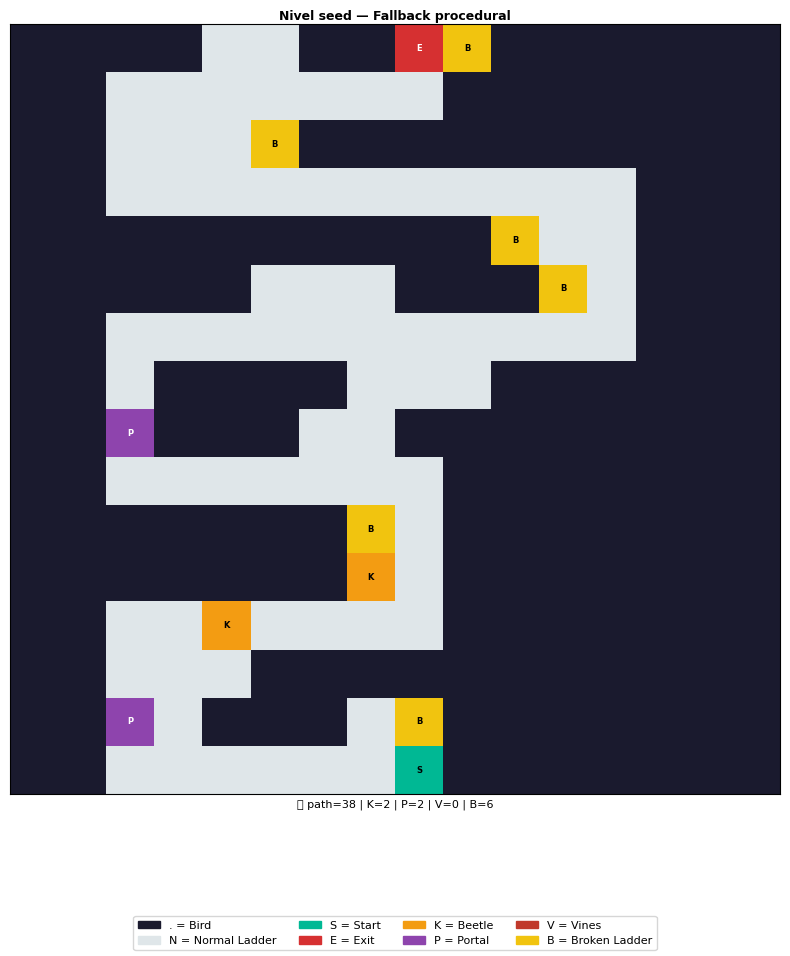

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# vizualizare nivel
def draw_level(ax, g, title='', val=None):
  H, W = len(g), len(g[0])
  img = np.zeros((H, W, 3))

  for r in range(H):
    for c in range(W):
      hx = COLORS.get(g[r][c], '#888')
      img[r, c] = [int(hx[1:3], 16)/255, int(hx[3:5], 16)/255, int(hx[5:7], 16)/255]

  ax.imshow(img, interpolation='nearest', aspect='equal')

  for r in range(H):
    for c in range(W):
      t = g[r][c]
      if t not in(0, 1):
        ax.text(c, r, TILE[t][0], ha='center', va='center', fontsize=6,
                        fontweight='bold', color='black' if t in (2, 4, 7) else 'white')

  ax.set_title(title, fontsize=9, fontweight='bold', pad=3)

  if val:
    m = val['metrics']
    ok = '✅' if val['valid'] else '❌'
    stats = (f"{ok} path={m.get('total_path','?')} | "
                 f"K={m.get('beetles','?')} | "
                 f"P={m.get('portals','?')} | "
                 f"V={m.get('vines','?')} | "
                 f"B={m.get('broken_ladders','?')}")
    ax.set_xlabel(stats, fontsize=8)

  ax.set_xticks([])
  ax.set_yticks([])

fig, ax = plt.subplots(figsize=(8, 10))
draw_level(ax, base, f'Nivel seed — {source}', v_final)

patches = [mpatches.Patch(color=COLORS[k], label=f"{TILE[k][0]} = {TILE[k][2]}") for k in sorted(TILE)]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

# **Implementare Algoritmi Genetici**

In [72]:
# definire nivel usor
def fit_easy(g):
    v = validate(g)
    if not v['valid']:
        return -1000.0

    m = v['metrics']
    vines = min(m.get('vines', 0), 5)

    # Penalizăm drastic orice pericol și penalizăm drumurile lungi
    return (
        - 2.0 * m.get('total_path', 0)     # Vrem drum cât mai scurt
        - 10.0 * m.get('beetles', 0)       # Fără gândaci
        - 15.0 * m.get('broken_ladders', 0)# Fără scări stricate
        + 5.0 * vines                      # Recompensăm lianele
    )

# definire nivel mediu
def fit_medium(g):
    v = validate(g)
    if not v['valid']:
        return -1000.0

    m = v['metrics']
    # Țintim un traseu mediu de ~25 pași, exact 3 gândaci și 1-2 scări stricate
    return (
        - 2.0 * abs(m.get('total_path', 0) - 25)
        - 4.0 * abs(m.get('beetles', 0) - 3)
        - 5.0 * abs(m.get('broken_ladders', 0) - 1)
        + 3.0 * min(m.get('vines', 0), 2)
    )

# definire nivel greu
def fit_hard(g):
    v = validate(g)
    if not v['valid']:
        return -1000.0

    m = v['metrics']
    beetles = m.get('beetles', 0)
    broken = m.get('broken_ladders', 0)

    score = 0.0

    # 1. RECOMPENSĂM efortul jucătorului (căderi, ocoluri)
    score += 4.0 * m.get('total_path', 0)

    # 2. PENALIZĂM piesele în exces ca să curățăm colțurile (limita maximă: 6 K, 4 B)
    if beetles > 6:
        score -= (beetles - 6) * 15.0
    if broken > 4:
        score -= (broken - 4) * 20.0

    # 3. Penalizăm lianele (ajutoarele)
    score -= m.get('vines', 0) * 10.0

    return score

FIT = {'easy':fit_easy,'medium':fit_medium,'hard':fit_hard}

# def mutate(g, rate=0.05, diff='medium'):
#   c = copy.deepcopy(g)

#   # Tile pool fără tile-uri speciale care trebuie să fie unice
#   pool = {
#       'easy':   [1, 1, 1, 1, 0, 6],       # Mai multe normal ladders și vianes
#       'medium': [1, 1, 0, 4, 6, 7],       # Mix echilibrat
#       'hard':   [1, 0, 0, 4, 4, 7, 7],    # Beetles și broken ladders
#   }.get(diff, [1, 1, 0, 6, 7])

#   for r in range(1, GRID_H-1):
#     for col in range(1, GRID_W-1):
#       t = c[r][col]
#       if t in (2, 3, 5):
#         continue    # nu atinge start/exit/portals
#       if random.random() < rate:
#         new_tile = random.choice(pool)

#         vecini = [c[r-1][col], c[r+1][col], c[r][col-1], c[r][col+1]]
#         # vine-ul trebuie plasat astfel incat sa fie loc cu 2 patratele mai sus
#         if new_tile == 6:
#           if (1 in vecini or t == 1) and (c[r-2][col] == 1):
#             c[r][col] = new_tile
#         # broken ladderul trebuie sa se
#         elif new_tile == 7:
#           if (1 in vecini or t == 1) and (c[r+1][col] == 1):
#             c[r][col] = new_tile
#         else:
#           c[r][col] = new_tile

#   c = fix_grid(c)
#   return c

def mutate(g, rate=0.05, diff='medium'):
    c = copy.deepcopy(g)

    # 1. Tile pool FĂRĂ '0' pentru a păstra drumul continuu
    # pool = {
    #     'easy':   [1, 1, 1, 1, 6],      # Multe scări normale și liane
    #     'medium': [1, 1, 4, 6, 7],      # Mix echilibrat
    #     'hard':   [1, 4, 4, 7, 7],      # Mulți gândaci și scări stricate
    # }.get(diff, [1, 1, 6, 7])
    pool = {
      'easy':   [1, 1, 1, 1, 1, 6],       # Mai multe normal ladders și vianes
      'medium': [1, 1, 1, 4, 6, 7],       # Mix echilibrat
      'hard':   [1, 1, 1, 4, 4, 7, 7],    # Beetles și broken ladders
  }.get(diff, [1, 1, 1, 6, 7])

    for r in range(1, GRID_H-1):
        for col in range(1, GRID_W-1):
            t = c[r][col]
            if t in (2, 3, 5):
                continue    # nu atinge start/exit/portals

            if random.random() < rate:
                new_tile = random.choice(pool)

                # Dacă mutația este o scară normală, o punem pur și simplu
                if new_tile == 1:
                    c[r][col] = 1
                    continue

                vecini = [c[r-1][col], c[r+1][col], c[r][col-1], c[r][col+1]]

                # 🚀 Liana (6)
                if new_tile == 6:
                    # Adăugăm r >= 2 ca să nu accesăm indexul -1
                    if r >= 2 and (t == 1) and (c[r-2][col] == 1):
                        c[r][col] = new_tile

                # ⛔ Scara stricată (7)
                elif new_tile == 7:
                    if (t == 1) and (c[r+1][col] == 1):
                        # Anti-clustering (nu le punem grămadă)
                        if 4 not in vecini and 7 not in vecini:
                            c[r][col] = new_tile

                # 👾 Gândacul (4)
                elif new_tile == 4:
                    if t == 1:
                        # Anti-clustering
                        if 4 not in vecini and 7 not in vecini:
                            c[r][col] = new_tile

    c = fix_grid(c)
    return c

def crossover(g1,g2):
  p1 = random.randint(1,GRID_H//3)
  p2 = random.randint(GRID_H//3*2,GRID_H-2)
  child = [copy.deepcopy(g1[r]) if r<p1 or r>p2 else copy.deepcopy(g2[r]) for r in range(GRID_H)]
  c = fix_grid(child)
  return c

def tournament(pop,scores,k=3):
  cands=random.sample(list(zip(pop,scores)),min(k,len(pop)))
  return max(cands,key=lambda x:x[1])[0]

def run_ga(seed, diff, pop_size=20, gens=30, elite=3):
  fn = FIT[diff]
  pop = [seed] + [mutate(seed, rate=0.08, diff=diff) for _ in range(pop_size-1)]
  history=[]
  for g in range(gens):
    scores = [fn(ind) for ind in pop]
    history.append(max(scores))
    if g%10 == 0 or g == gens-1:
      valid_n = sum(1 for s in scores if s>-1000)
      print(f'  [{diff}] gen={g:3d} best={max(scores):8.2f} valid={valid_n}/{pop_size}')

    pairs = sorted(zip(scores,pop), key=lambda x:-x[0])
    new = [copy.deepcopy(ind) for _,ind in pairs[:elite]]
    while len(new) < pop_size:
      p1 = tournament(pop, scores)
      child = crossover(p1, tournament(pop,scores)) if random.random()<0.6 else copy.deepcopy(p1)
      new.append(mutate(child,diff=diff))
    pop = new
  final = [fn(ind) for ind in pop]
  best = pop[int(np.argmax(final))]
  return best, history

# testare pe harta generata de llm
ga_results = {}
ga_histories = {}
for diff in['easy', 'medium', 'hard']:
  print(f'\n🧬 GA [{diff.upper()}]')

  best, hist = run_ga(base, diff)
  ga_results[diff] = best
  ga_histories[diff] = hist
  v = validate(best)

  print(f'   ✅ valid={v["valid"]} | {v["metrics"]}')
print('\n🏁 GA complet!')



🧬 GA [EASY]
  [easy] gen=  0 best=  -86.00 valid=17/20
  [easy] gen= 10 best=  -24.00 valid=20/20
  [easy] gen= 20 best=  -14.00 valid=20/20
  [easy] gen= 29 best=  -10.00 valid=20/20
   ✅ valid=True | {'path_s_e': 10, 'total_path': 10, 'beetles': 0, 'portals': 2, 'vines': 9, 'broken_ladders': 1, 'floor': 86}

🧬 GA [MEDIUM]
  [medium] gen=  0 best=  -22.00 valid=20/20
  [medium] gen= 10 best=   -9.00 valid=20/20
  [medium] gen= 20 best=   -5.00 valid=15/20
  [medium] gen= 29 best=   -5.00 valid=14/20
   ✅ valid=True | {'path_s_e': 22, 'total_path': 22, 'beetles': 3, 'portals': 2, 'vines': 2, 'broken_ladders': 2, 'floor': 77}

🧬 GA [HARD]
  [hard] gen=  0 best=  112.00 valid=17/20
  [hard] gen= 10 best=  112.00 valid=17/20
  [hard] gen= 20 best=  112.00 valid=16/20
  [hard] gen= 29 best=  112.00 valid=14/20
   ✅ valid=True | {'path_s_e': 38, 'total_path': 38, 'beetles': 2, 'portals': 2, 'vines': 0, 'broken_ladders': 6, 'floor': 82}

🏁 GA complet!


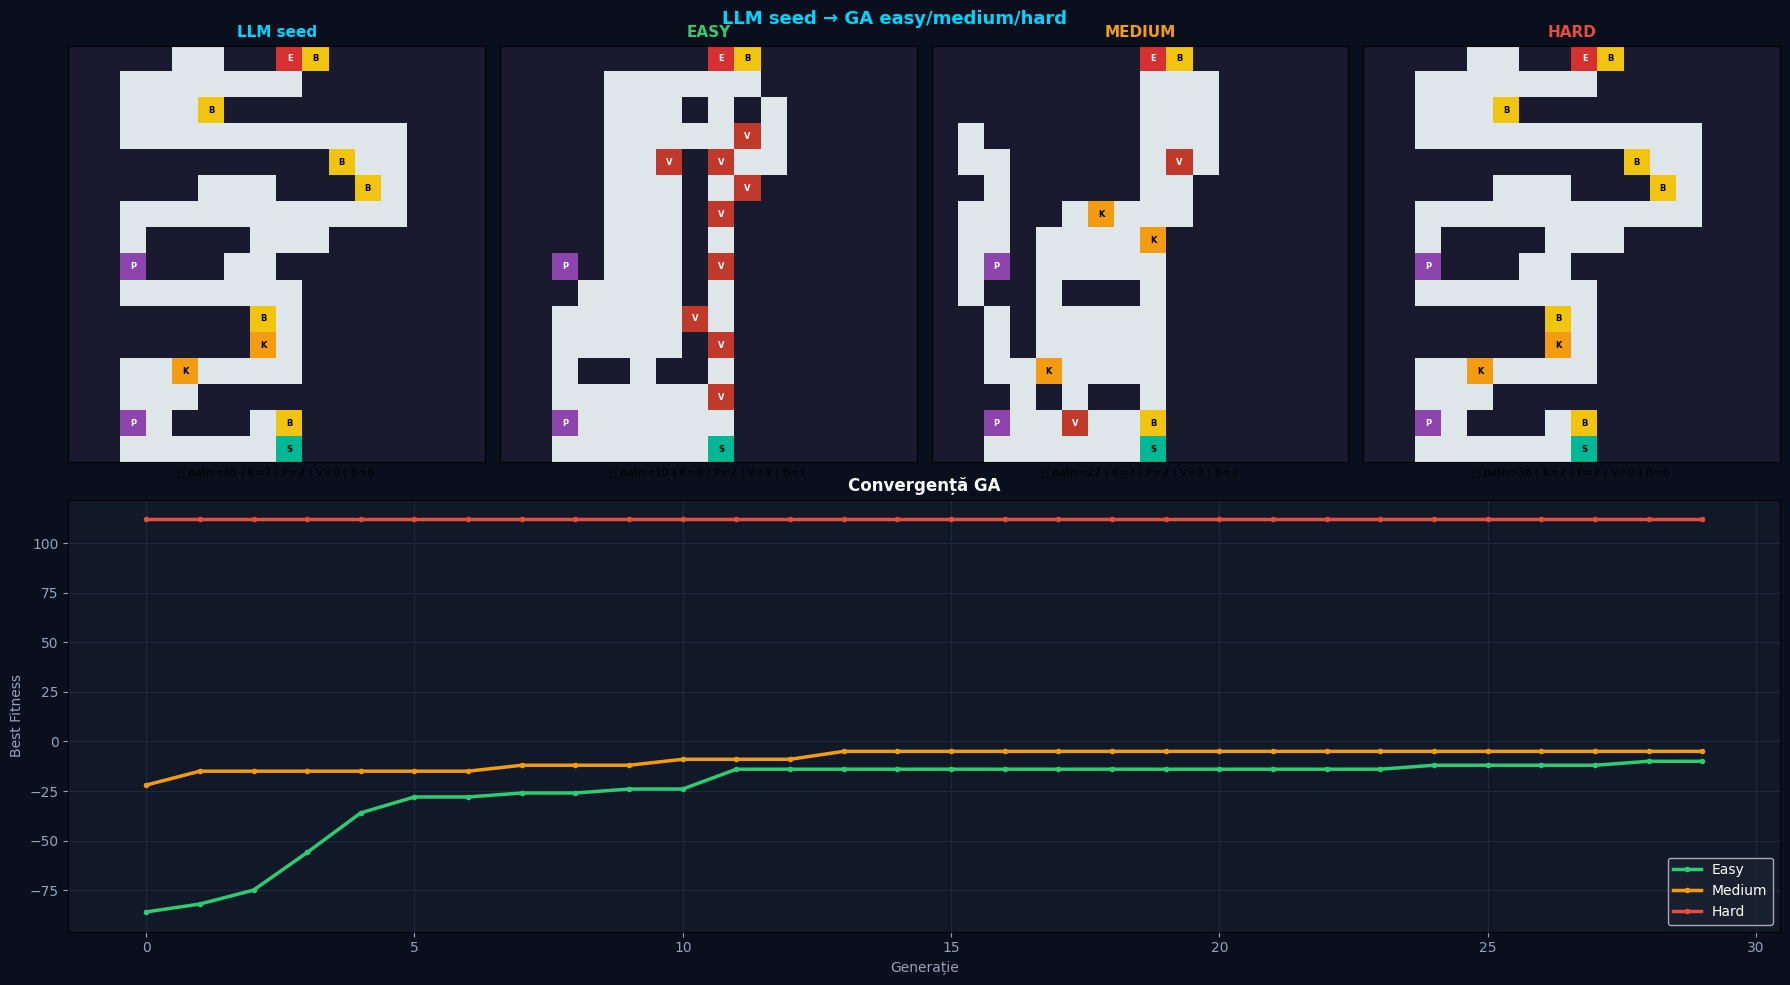

✅ Niveluri selectate pentru Q-Learning:
  easy: valid=True | {'path_s_e': 10, 'total_path': 10, 'beetles': 0, 'portals': 2, 'vines': 9, 'broken_ladders': 1, 'floor': 86}
  medium: valid=True | {'path_s_e': 22, 'total_path': 22, 'beetles': 3, 'portals': 2, 'vines': 2, 'broken_ladders': 2, 'floor': 77}
  hard: valid=True | {'path_s_e': 38, 'total_path': 38, 'beetles': 2, 'portals': 2, 'vines': 0, 'broken_ladders': 6, 'floor': 82}


In [73]:
# vizuarilizare niveluri create
fig = plt.figure(figsize=(18,10))
fig.patch.set_facecolor('#0A0F1E')
DCOL = {'easy':'#2ecc71','medium':'#f39c12','hard':'#e74c3c'}

all_lv = [('LLM seed',base,'#00D4FF')] + [(d.upper(),ga_results[d],DCOL[d]) for d in['easy','medium','hard']]
for i, (lbl,g,col) in enumerate(all_lv):
    ax = fig.add_subplot(2,4,i+1); ax.set_facecolor('#0A0F1E')
    draw_level(ax,g,lbl,validate(g))
    ax.set_title(lbl,color=col,fontsize=11,fontweight='bold')

ax2 = fig.add_subplot(2,4,(5,8))
ax2.set_facecolor('#111827')
for diff,col in DCOL.items():
    ax2.plot(ga_histories[diff],color=col,lw=2.5,label=diff.capitalize(),marker='o',ms=3)

ax2.set_title('Convergență GA',color='white',fontsize=12,fontweight='bold')
ax2.set_xlabel('Generație',color='#94A3B8')
ax2.set_ylabel('Best Fitness',color='#94A3B8')

ax2.legend(fontsize=10,facecolor='#1A2333',labelcolor='white')
ax2.grid(True,color='#1E293B')
ax2.tick_params(colors='#94A3B8')
plt.suptitle('LLM seed → GA easy/medium/hard',color='#00D4FF',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()

ql_levels = {d:ga_results[d] for d in['easy','medium','hard']}
print('✅ Niveluri selectate pentru Q-Learning:')
for d,g in ql_levels.items():
    v = validate(g)
    print(f'  {d}: valid={v["valid"]} | {v["metrics"]}')
